# 07 · Support vector machines: `src/svm/`

Tests for `SVC` / `SVM` (classification), `SVR` (regression) and the utilities in `_svm_utils.py`: the kernels, `KFold`, `StratifiedKFold`, `GridSearchCV` and the metrics.

| Data | Source | What it tests |
|---|---|---|
| Separable blobs, moons, circles (2-D) | generated | linear vs RBF/poly kernels, margins and support vectors |
| Breast Cancer, Iris | scikit-learn, bundled | accuracy vs scikit-learn's `SVC`, one-vs-rest multi-class |
| Noisy sine, Diabetes | generated / bundled | `SVR` and the ε-tube |
| Imbalanced 92/8 data | generated | the no-bias pitfall and rebalancing |
| Ionosphere (351 × 34) | **online** (UCI id 52) | real-world radar-signal classification |

In [1]:
%matplotlib inline
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets, svm as sksvm, metrics as skm
from sklearn.metrics import pairwise
from sklearn.model_selection import train_test_split

from _testkit import SEED, Checks, load_online, timed
from src.svm._svc import SVC
from src.svm._svr import SVR
from src.svm._svm import SVM, NotFittedError, ConvergenceWarning
from src.svm._svm_utils import (
    KFold, StratifiedKFold, GridSearchCV, rbf_kernel, poly_kernel,
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report,
)

checks = Checks("07 svm")
rng = np.random.default_rng(SEED)


def plot_svm(ax, model, X, y, title):
    # Decision regions, the f(x) = 0 boundary and the support vectors.
    xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 250),
                         np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 250))
    f = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, f > 0, alpha=0.25, cmap="coolwarm")
    ax.contour(xx, yy, f, levels=[0], colors="k", linewidths=1.5)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=12, edgecolor="k", linewidth=0.2)
    if hasattr(model, "support_vectors_"):
        sv = model.scaler.mean_ + model.support_vectors_ * model.scaler.std_   # back to input space
        ax.scatter(sv[:, 0], sv[:, 1], s=45, facecolors="none", edgecolors="lime", linewidths=1, label="support vectors")
        ax.legend(loc="lower right", fontsize=8)
    ax.set_title(title)

## 1. Kernels match scikit-learn

In [2]:
A, B = rng.normal(size=(40, 5)), rng.normal(size=(30, 5))
for g in [0.1, 1.0]:
    checks.close(f"rbf_kernel(γ={g}) == sklearn", rbf_kernel(A, B, gamma=g), pairwise.rbf_kernel(A, B, gamma=g), atol=1e-12)
    checks.close(f"poly_kernel(γ={g}, d=3) == sklearn", poly_kernel(A, B, degree=3, gamma=g),
                 pairwise.polynomial_kernel(A, B, degree=3, gamma=g, coef0=1.0), rtol=1e-10)
K = rbf_kernel(A)
checks.close("rbf_kernel(X) is symmetric with a unit diagonal", np.r_[np.diag(K), (K - K.T).ravel()], np.r_[np.ones(40), np.zeros(1600)])
checks.check("rbf kernel matrix is positive semi-definite", np.linalg.eigvalsh(K).min() > -1e-10)

✅ rbf_kernel(γ=0.1) == sklearn  (max |Δ| = 2.22e-16)
✅ poly_kernel(γ=0.1, d=3) == sklearn  (max |Δ| = 0.00e+00)
✅ rbf_kernel(γ=1.0) == sklearn  (max |Δ| = 9.99e-16)
✅ poly_kernel(γ=1.0, d=3) == sklearn  (max |Δ| = 0.00e+00)
✅ rbf_kernel(X) is symmetric with a unit diagonal  (max |Δ| = 6.66e-16)
✅ rbf kernel matrix is positive semi-definite


True

## 2. Cross-validation splitters

The test folds must partition the data, so every index appears in exactly one test fold. `StratifiedKFold` must also keep the class ratio in every fold, even when the data is sorted by class.

In [3]:
n = 103
X_dummy = np.zeros((n, 1))
y_sorted = np.repeat([0, 1, 2], [60, 30, 13])            # class-ordered and imbalanced

for name, splitter, args in [("KFold", KFold(5), (X_dummy,)), ("KFold(shuffle)", KFold(5, shuffle=True, random_state=0), (X_dummy,)),
                             ("StratifiedKFold", StratifiedKFold(5, shuffle=True, random_state=0), (X_dummy, y_sorted))]:
    folds = list(splitter.split(*args))
    test_idx = np.concatenate([te for _, te in folds])
    checks.check(f"{name}: {splitter.get_n_splits()} folds", len(folds) == 5 == splitter.get_n_splits())
    checks.check(f"{name}: test folds partition all samples", np.array_equal(np.sort(test_idx), np.arange(n)))
    checks.check(f"{name}: train ∩ test = ∅ in every fold", all(len(np.intersect1d(tr, te)) == 0 and len(tr) + len(te) == n for tr, te in folds))
    checks.check(f"{name}: fold sizes differ by at most 1", np.ptp([len(te) for _, te in folds]) <= 1 or name == "StratifiedKFold")

ratios = np.array([np.bincount(y_sorted[te], minlength=3) / len(te) for _, te in StratifiedKFold(5, shuffle=True, random_state=0).split(X_dummy, y_sorted)])
checks.at_most("StratifiedKFold: class ratios stay within 0.05 of the overall ratio",
               np.abs(ratios - np.bincount(y_sorted) / n).max(), 0.05)
first_fold = next(KFold(5).split(X_dummy))[1]
checks.check("KFold without shuffle keeps order (first fold = first 21 samples)", np.array_equal(first_fold, np.arange(21)))

✅ KFold: 5 folds
✅ KFold: test folds partition all samples
✅ KFold: train ∩ test = ∅ in every fold
✅ KFold: fold sizes differ by at most 1
✅ KFold(shuffle): 5 folds
✅ KFold(shuffle): test folds partition all samples
✅ KFold(shuffle): train ∩ test = ∅ in every fold
✅ KFold(shuffle): fold sizes differ by at most 1
✅ StratifiedKFold: 5 folds
✅ StratifiedKFold: test folds partition all samples
✅ StratifiedKFold: train ∩ test = ∅ in every fold
✅ StratifiedKFold: fold sizes differ by at most 1
✅ StratifiedKFold: class ratios stay within 0.05 of the overall ratio  (0.0262 ≤ 0.05)
✅ KFold without shuffle keeps order (first fold = first 21 samples)


True

## 3. Linear vs non-linear kernels on 2-D data

Linearly separable blobs are easy for a linear SVM. Moons and circles need a kernel: a linear model can do no better than about 50 % on circles.

✅ linear solver emits ConvergenceWarning when it hits max_iter


✅ linear kernel: separable blobs  (1.0000 ≥ 0.99)
✅ rbf kernel: moons  (0.9933 ≥ 0.95)
✅ rbf kernel: circles  (1.0000 ≥ 0.95)
✅ poly (degree 2) kernel: circles  (1.0000 ≥ 0.95)
✅ linear kernel cannot solve circles  (0.5900 ≤ 0.7)
✅ linear weight vector ∥ sklearn's (cosine)  (0.9991 ≥ 0.95)


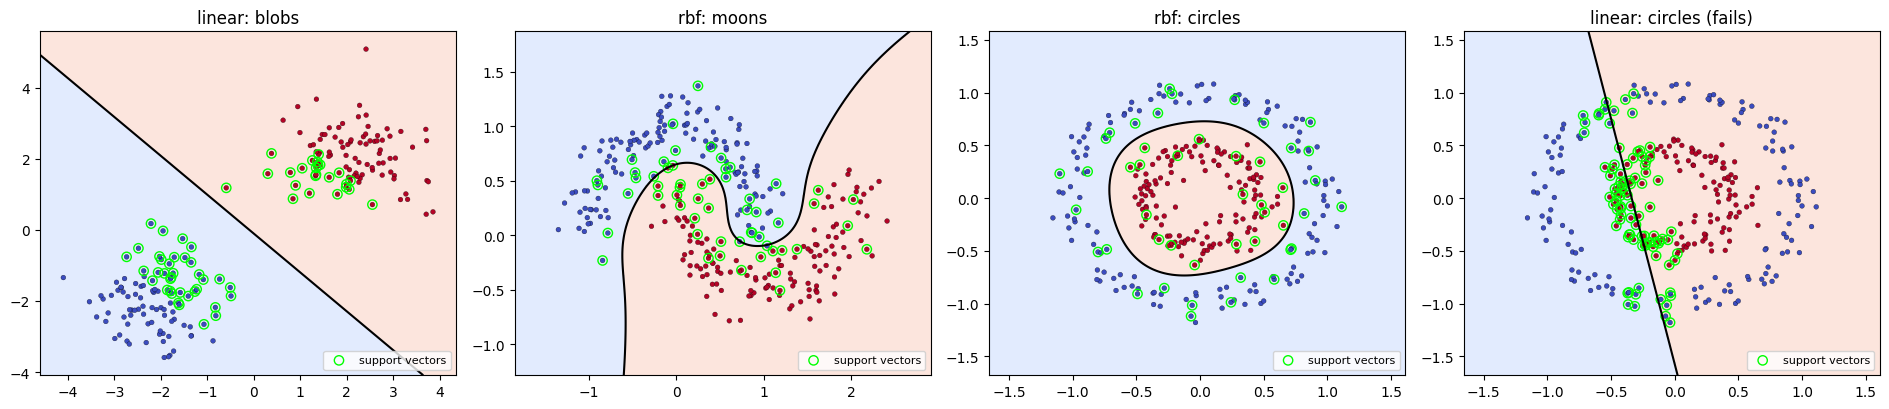

In [4]:
X_lin, y_lin = datasets.make_blobs(n_samples=200, centers=[[-2, -2], [2, 2]], cluster_std=0.8, random_state=SEED)
X_moon, y_moon = datasets.make_moons(n_samples=300, noise=0.15, random_state=SEED)
X_circ, y_circ = datasets.make_circles(n_samples=300, noise=0.08, factor=0.45, random_state=SEED)

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    m_lin = SVC(kernel="linear", C=1.0).fit(X_lin, y_lin)
    SVC(kernel="linear", C=1.0).fit(X_circ, y_circ)              # impossible problem → hits max_iter
checks.check("linear solver emits ConvergenceWarning when it hits max_iter", any(issubclass(w.category, ConvergenceWarning) for w in caught))
warnings.filterwarnings("ignore", category=ConvergenceWarning)    # keep the rest of the notebook readable

m_moon = SVC(kernel="rbf", C=10.0, gamma=1.0).fit(X_moon, y_moon)
m_circ = SVC(kernel="rbf", C=10.0, gamma=1.0).fit(X_circ, y_circ)
m_poly = SVC(kernel="poly", C=1.0, degree=2).fit(X_circ, y_circ)
m_circ_lin = SVC(kernel="linear").fit(X_circ, y_circ)

checks.at_least("linear kernel: separable blobs", m_lin.score(X_lin, y_lin), 0.99)
checks.at_least("rbf kernel: moons", m_moon.score(X_moon, y_moon), 0.95)
checks.at_least("rbf kernel: circles", m_circ.score(X_circ, y_circ), 0.95)
checks.at_least("poly (degree 2) kernel: circles", m_poly.score(X_circ, y_circ), 0.95)
checks.at_most("linear kernel cannot solve circles", m_circ_lin.score(X_circ, y_circ), 0.7)

ref_lin = sksvm.SVC(kernel="linear", C=1.0).fit((X_lin - X_lin.mean(0)) / X_lin.std(0), y_lin)
cos = m_lin.weight_ @ ref_lin.coef_.ravel() / (np.linalg.norm(m_lin.weight_) * np.linalg.norm(ref_lin.coef_))
checks.at_least("linear weight vector ∥ sklearn's (cosine)", float(cos), 0.95)

fig, axes = plt.subplots(1, 4, figsize=(19, 4.2))
plot_svm(axes[0], m_lin, X_lin, y_lin, "linear: blobs")
plot_svm(axes[1], m_moon, X_moon, y_moon, "rbf: moons")
plot_svm(axes[2], m_circ, X_circ, y_circ, "rbf: circles")
plot_svm(axes[3], m_circ_lin, X_circ, y_circ, "linear: circles (fails)")
plt.tight_layout(); plt.show()

### Effect of `C` and `γ`

A small `C` tolerates margin violations (smoother boundary, more support vectors). A large `γ` makes each support vector's influence very local, which can overfit.

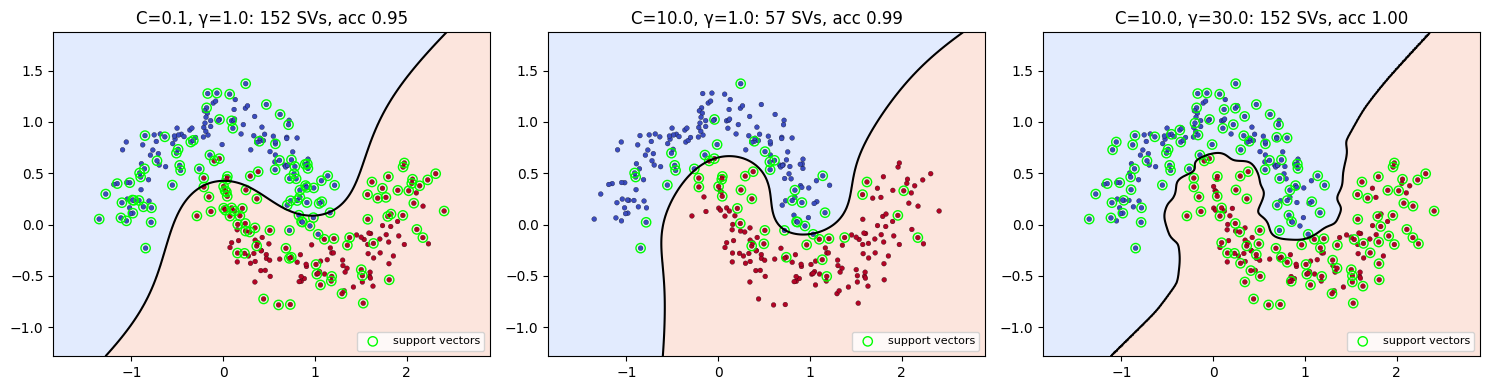

✅ smaller C → more support vectors  (152 vs 57)


True

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
n_sv = {}
for ax, (C, gamma) in zip(axes, [(0.1, 1.0), (10.0, 1.0), (10.0, 30.0)]):
    m = SVC(kernel="rbf", C=C, gamma=gamma).fit(X_moon, y_moon)
    n_sv[(C, gamma)] = m.n_support_
    plot_svm(ax, m, X_moon, y_moon, f"C={C}, γ={gamma}: {m.n_support_} SVs, acc {m.score(X_moon, y_moon):.2f}")
plt.tight_layout(); plt.show()
checks.check("smaller C → more support vectors", n_sv[(0.1, 1.0)] > n_sv[(10.0, 1.0)], f"{n_sv[(0.1, 1.0)]} vs {n_sv[(10.0, 1.0)]}")

## 4. Real data: Breast Cancer and multi-class Iris

`SVC` standardises its inputs internally, so we pass raw features. We give scikit-learn's `SVC` scaled features so the two see the same geometry.

In [6]:
X_bc, y_bc = datasets.load_breast_cancer(return_X_y=True)
Xtr, Xte, ytr, yte = train_test_split(X_bc, y_bc, test_size=0.3, random_state=SEED, stratify=y_bc)
mu, sd = Xtr.mean(0), Xtr.std(0)

rows = []
for kernel in ["linear", "rbf", "poly"]:
    with timed(f"SVC({kernel}) on Breast Cancer"):
        ours = SVC(kernel=kernel, C=1.0, random_state=SEED).fit(Xtr, ytr)
    ref = sksvm.SVC(kernel=kernel, C=1.0, gamma=1 / Xtr.shape[1], coef0=1.0).fit((Xtr - mu) / sd, ytr)
    rows.append({"kernel": kernel, "ours": ours.score(Xte, yte), "sklearn": ref.score((Xte - mu) / sd, yte)})
    checks.at_least(f"Breast Cancer {kernel}: test accuracy", rows[-1]["ours"], 0.93)
    checks.at_most(f"Breast Cancer {kernel}: |ours − sklearn|", abs(rows[-1]["ours"] - rows[-1]["sklearn"]), 0.04)
display(pd.DataFrame(rows).round(4))

X_iris, y_iris = datasets.load_iris(return_X_y=True)
Xa, Xb, ya, yb = train_test_split(X_iris, y_iris, test_size=0.3, random_state=SEED, stratify=y_iris)
ovr = SVC(kernel="rbf", C=1.0).fit(Xa, ya)
scores = ovr.decision_function(Xb)
checks.check("multi-class: decision_function has one column per class", scores.shape == (len(Xb), 3))
checks.check("multi-class: predict == argmax of OvR scores", np.array_equal(ovr.predict(Xb), ovr.classes_[scores.argmax(1)]))
checks.at_least("Iris (one-vs-rest): test accuracy", ovr.score(Xb, yb), 0.9)
y_named = np.array(["setosa", "versicolor", "virginica"])[ya]
checks.known_bug("string class labels are supported", lambda: set(SVC().fit(Xa, y_named).predict(Xb)) <= set(y_named),
                 "_validate_input calls np.isnan(y), which raises TypeError for string labels")

⏱️ SVC(linear) on Breast Cancer: 1.12s
✅ Breast Cancer linear: test accuracy  (0.9766 ≥ 0.93)
✅ Breast Cancer linear: |ours − sklearn|  (0.0058 ≤ 0.04)
⏱️ SVC(rbf) on Breast Cancer: 0.02s
✅ Breast Cancer rbf: test accuracy  (0.9591 ≥ 0.93)
✅ Breast Cancer rbf: |ours − sklearn|  (0.0175 ≤ 0.04)
⏱️ SVC(poly) on Breast Cancer: 0.01s
✅ Breast Cancer poly: test accuracy  (0.9591 ≥ 0.93)
✅ Breast Cancer poly: |ours − sklearn|  (0.0292 ≤ 0.04)


,kernel,ours,sklearn
0,linear,0.9766,0.9825
1,rbf,0.9591,0.9766
2,poly,0.9591,0.9883


✅ multi-class: decision_function has one column per class
✅ multi-class: predict == argmax of OvR scores
✅ Iris (one-vs-rest): test accuracy  (0.9111 ≥ 0.9)
🐞 string class labels are supported  (_validate_input calls np.isnan(y), which raises TypeError for string labels | TypeError: ufunc 'isnan' not supported for the input types, and the inputs could n)


False

## 5. `GridSearchCV`

In [7]:
grid = {"C": [0.1, 1, 10], "gamma": [0.1, 1.0, 5.0]}
with timed("GridSearchCV: 9 combos × 5 folds on moons"):
    gs = GridSearchCV(SVC(kernel="rbf"), grid, cv=StratifiedKFold(5, shuffle=True, random_state=SEED)).fit(X_moon, y_moon)
res = pd.DataFrame(gs.cv_results_["params"]).assign(mean_test_score=gs.cv_results_["mean_test_score"])
display(res.pivot(index="C", columns="gamma", values="mean_test_score").round(3))

checks.check("cv_results_ has one row per combination", len(res) == 9)
checks.close("best_score_ == max mean_test_score", gs.best_score_, res.mean_test_score.max())
checks.check("best_params_ is the argmax combination", gs.best_params_ == res.iloc[res.mean_test_score.argmax()][["C", "gamma"]].to_dict())
checks.check("best_estimator_ uses best_params_", gs.best_estimator_.C == gs.best_params_["C"] and gs.best_estimator_.gamma == gs.best_params_["gamma"])
checks.check("best_estimator_ is refit on all data (score defined)", 0 <= gs.best_estimator_.score(X_moon, y_moon) <= 1)
checks.check("integer cv picks StratifiedKFold for classifiers", isinstance(GridSearchCV(SVC(), grid, cv=3).cv, StratifiedKFold))
checks.check("integer cv picks KFold for regressors", isinstance(GridSearchCV(SVR(), {"C": [1]}, cv=3).cv, KFold))
p = SVC().set_params(C=3.0, kernel="poly").get_params()
checks.check("get_params / set_params round-trip", p["C"] == 3.0 and p["kernel"] == "poly")

⏱️ GridSearchCV: 9 combos × 5 folds on moons: 0.24s


gamma,0.1,1.0,5.0
C,,,
0.1,0.850,0.943,0.983
1.0,0.867,0.983,0.987
10.0,0.887,0.990,0.997


✅ cv_results_ has one row per combination
✅ best_score_ == max mean_test_score  (max |Δ| = 0.00e+00)
✅ best_params_ is the argmax combination
✅ best_estimator_ uses best_params_
✅ best_estimator_ is refit on all data (score defined)
✅ integer cv picks StratifiedKFold for classifiers
✅ integer cv picks KFold for regressors
✅ get_params / set_params round-trip


True

## 6. `SVR`: regression with an ε-insensitive tube

Points inside the ε-tube cost nothing, so they are not support vectors. A wider `ε` therefore gives fewer support vectors.

✅ SVR fits a noisy sine (R²)  (0.9807 ≥ 0.95)
✅ wider ε → fewer support vectors  (142 < 200)
✅ SVR.score == sklearn r2_score  (max |Δ| = 0.00e+00)


✅ targets are standardised internally (same fit at 1000× scale)  (0.9807 ≥ 0.95)


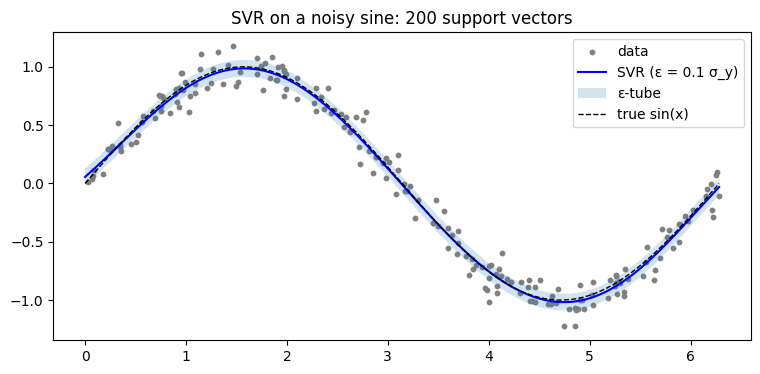

Diabetes test R²  ours: 0.4670 | sklearn (same scaling): 0.4885
✅ Diabetes SVR test R²  (0.4670 ≥ 0.35)
✅ Diabetes: |ours − sklearn| R²  (0.0215 ≤ 0.08)


True

In [8]:
X_sin = np.sort(rng.uniform(0, 2 * np.pi, 200))[:, None]
y_sin = np.sin(X_sin).ravel() + rng.normal(scale=0.1, size=200)
svr = SVR(kernel="rbf", C=10.0, epsilon=0.1).fit(X_sin, y_sin)
svr_wide = SVR(kernel="rbf", C=10.0, epsilon=0.5).fit(X_sin, y_sin)
checks.at_least("SVR fits a noisy sine (R²)", svr.score(X_sin, y_sin), 0.95)
checks.check("wider ε → fewer support vectors", svr_wide.n_support_ < svr.n_support_, f"{svr_wide.n_support_} < {svr.n_support_}")
checks.close("SVR.score == sklearn r2_score", svr.score(X_sin, y_sin), skm.r2_score(y_sin, svr.predict(X_sin)))

y_big = 1000 * y_sin + 5000                                   # targets on a different scale
checks.at_least("targets are standardised internally (same fit at 1000× scale)", SVR(C=10.0, epsilon=0.1).fit(X_sin, y_big).score(X_sin, y_big), 0.95)

grid_x = np.linspace(0, 2 * np.pi, 400)[:, None]
eps_y = svr.epsilon * np.std(y_sin)                           # ε is in standardised-y units
plt.figure(figsize=(9, 4))
plt.scatter(X_sin, y_sin, s=10, c="gray", label="data")
plt.plot(grid_x, svr.predict(grid_x), "b", label="SVR (ε = 0.1 σ_y)")
plt.fill_between(grid_x.ravel(), svr.predict(grid_x) - eps_y, svr.predict(grid_x) + eps_y, alpha=0.2, label="ε-tube")
plt.plot(grid_x, np.sin(grid_x), "k--", lw=1, label="true sin(x)")
plt.legend(); plt.title(f"SVR on a noisy sine: {svr.n_support_} support vectors"); plt.show()

X_dia, y_dia = datasets.load_diabetes(return_X_y=True)
Xa, Xb, ya, yb = train_test_split(X_dia, y_dia, test_size=0.3, random_state=SEED)
ours = SVR(kernel="rbf", C=1.0, epsilon=0.1).fit(Xa, ya)
m, s = Xa.mean(0), Xa.std(0); ym, ys = ya.mean(), ya.std()
ref = sksvm.SVR(kernel="rbf", C=1.0, epsilon=0.1, gamma=1 / Xa.shape[1]).fit((Xa - m) / s, (ya - ym) / ys)
r2_ref = skm.r2_score(yb, ref.predict((Xb - m) / s) * ys + ym)
print(f"Diabetes test R²  ours: {ours.score(Xb, yb):.4f} | sklearn (same scaling): {r2_ref:.4f}")
checks.at_least("Diabetes SVR test R²", ours.score(Xb, yb), 0.35)
checks.at_most("Diabetes: |ours − sklearn| R²", abs(ours.score(Xb, yb) - r2_ref), 0.08)

## 7. Pitfall: imbalanced data and the missing bias term

The kernel decision function `f(x) = Σ αⱼ yⱼ K(xⱼ, x)` has **no intercept**. On imbalanced data the majority class contributes most of the terms, which pushes predictions toward it. Over-sampling the minority class in the training set restores the balance.

In [9]:
X_imb, y_imb = datasets.make_classification(n_samples=1500, n_features=8, n_informative=5, weights=[0.92, 0.08],
                                            class_sep=0.8, flip_y=0.02, random_state=SEED)
Xa, Xb, ya, yb = train_test_split(X_imb, y_imb, test_size=0.4, random_state=SEED, stratify=y_imb)
naive = SVC(kernel="rbf", C=1.0).fit(Xa, ya)

minority = np.flatnonzero(ya == 1)
extra = np.random.default_rng(SEED).choice(minority, (ya == 0).sum() - len(minority), replace=True)
Xo, yo = np.vstack([Xa, Xa[extra]]), np.r_[ya, ya[extra]]
balanced = SVC(kernel="rbf", C=1.0).fit(Xo, yo)

r_naive, r_bal = recall_score(yb, naive.predict(Xb), pos_label=1), recall_score(yb, balanced.predict(Xb), pos_label=1)
print(f"minority recall  naive: {r_naive:.3f} | over-sampled: {r_bal:.3f}")
print(classification_report(yb, balanced.predict(Xb)))
checks.check("over-sampling raises minority-class recall", r_bal > r_naive + 0.1, f"{r_bal:.3f} vs {r_naive:.3f}")

minority recall  naive: 0.164 | over-sampled: 0.564
              precision  recall  f1-score  support
             0  0.9543   0.9193    0.9364    545
             1  0.4133   0.5636    0.4769    55

      accuracy                              0.8867    600

✅ over-sampling raises minority-class recall  (0.564 vs 0.164)


True

## 8. Metrics match scikit-learn

In [10]:
yt, yp = rng.integers(0, 2, 300), rng.integers(0, 2, 300)
checks.close("accuracy_score == sklearn", accuracy_score(yt, yp), skm.accuracy_score(yt, yp))
checks.close("precision_score == sklearn", precision_score(yt, yp), skm.precision_score(yt, yp))
checks.close("recall_score == sklearn", recall_score(yt, yp), skm.recall_score(yt, yp))
checks.close("f1_score == sklearn", f1_score(yt, yp), skm.f1_score(yt, yp))
checks.close("pos_label=0 matches sklearn", precision_score(yt, yp, pos_label=0), skm.precision_score(yt, yp, pos_label=0))
cm, labels = confusion_matrix(yt, yp)
checks.check("confusion_matrix == sklearn (with label order)", np.array_equal(cm, skm.confusion_matrix(yt, yp)) and list(labels) == [0, 1])
y3t, y3p = rng.integers(0, 3, 200), rng.integers(0, 3, 200)
cm3, _ = confusion_matrix(y3t, y3p)
checks.check("3-class confusion_matrix == sklearn", np.array_equal(cm3, skm.confusion_matrix(y3t, y3p)))

✅ accuracy_score == sklearn  (max |Δ| = 0.00e+00)
✅ precision_score == sklearn  (max |Δ| = 0.00e+00)
✅ recall_score == sklearn  (max |Δ| = 0.00e+00)
✅ f1_score == sklearn  (max |Δ| = 1.11e-16)
✅ pos_label=0 matches sklearn  (max |Δ| = 0.00e+00)
✅ confusion_matrix == sklearn (with label order)
✅ 3-class confusion_matrix == sklearn


True

## 9. Real data (online): Ionosphere

351 radar returns from the ionosphere, each with 34 continuous features, labelled *good* or *bad*. This is a classic SVM benchmark where an RBF kernel reaches about 94 %.

In [11]:
def _ionosphere():
    from ucimlrepo import fetch_ucirepo
    d = fetch_ucirepo(id=52)
    return d.data.features.to_numpy(float), (d.data.targets.iloc[:, 0] == "g").to_numpy().astype(int)

iono, online = load_online("Ionosphere (UCI 52)", _ionosphere)
if online:
    Xi, yi = iono
    Xa, Xb, ya, yb = train_test_split(Xi, yi, test_size=0.3, random_state=SEED, stratify=yi)
    with timed("GridSearchCV on Ionosphere (9 combos × 5 folds)"):
        gsi = GridSearchCV(SVC(kernel="rbf"), {"C": [1, 10, 100], "gamma": [0.01, 0.05, None]}, cv=5).fit(Xa, ya)
    acc_i = gsi.best_estimator_.score(Xb, yb)
    print("best params:", gsi.best_params_, f"| CV {gsi.best_score_:.4f} | test {acc_i:.4f}")
    checks.at_least("Ionosphere: tuned RBF test accuracy", acc_i, 0.9)
    checks.at_least("Ionosphere: RBF beats linear", acc_i - SVC(kernel="linear").fit(Xa, ya).score(Xb, yb), 0.0)
else:
    checks.skip("Ionosphere checks", "dataset unavailable offline")

🌐 Ionosphere (UCI 52): downloaded / loaded from cache


⏱️ GridSearchCV on Ionosphere (9 combos × 5 folds): 0.47s
best params: {'C': 10, 'gamma': 0.05} | CV 0.9148 | test 0.9245
✅ Ionosphere: tuned RBF test accuracy  (0.9245 ≥ 0.9)


✅ Ionosphere: RBF beats linear  (0.0189 ≥ 0.0)


## 10. API contract and validation

In [12]:
m = SVC()
checks.check("fit() returns self", m.fit(X_moon, y_moon) is m)
checks.check("SVC is a subclass of SVM", issubclass(SVC, SVM))
a = SVC(kernel="rbf").fit(X_moon, y_moon).decision_function(X_moon)
b = SVC(kernel="rbf").fit(X_moon, y_moon).decision_function(X_moon)
checks.check("deterministic: repeated fits are identical", np.array_equal(a, b))
checks.raises("predict before fit raises NotFittedError", NotFittedError, lambda: SVC().predict(X_moon))
checks.raises("SVR predict before fit raises NotFittedError", NotFittedError, lambda: SVR().predict(X_moon))
checks.raises("unknown kernel raises", ValueError, lambda: SVC(kernel="sigmoid").fit(X_moon, y_moon))
checks.raises("C ≤ 0 raises", ValueError, lambda: SVC(C=0).fit(X_moon, y_moon))
checks.raises("gamma ≤ 0 raises", ValueError, lambda: SVC(gamma=-1.0).fit(X_moon, y_moon))
checks.raises("negative epsilon raises", ValueError, lambda: SVR(epsilon=-0.1).fit(X_sin, y_sin))
checks.raises("single-class y raises", ValueError, lambda: SVC().fit(X_moon, np.zeros(len(X_moon))))
checks.raises("empty X raises", ValueError, lambda: SVC().fit(np.empty((0, 2)), np.empty(0)))

✅ fit() returns self
✅ SVC is a subclass of SVM
✅ deterministic: repeated fits are identical
✅ predict before fit raises NotFittedError  (NotFittedError: SVC is not fitted yet. Call 'fit' before 'predict' or 'decision_function'.)
✅ SVR predict before fit raises NotFittedError  (NotFittedError: SVR is not fitted yet. Call 'fit' before 'predict' or 'decision_function'.)
✅ unknown kernel raises  (ValueError: kernel must be 'linear', 'rbf', or 'poly'. Got 'sigmoid'.)
✅ C ≤ 0 raises  (ValueError: C must be > 0. Got C=0.)
✅ gamma ≤ 0 raises  (ValueError: gamma must be > 0 or None. Got gamma=-1.0.)
✅ negative epsilon raises  (ValueError: epsilon must be >= 0. Got epsilon=-0.1.)
✅ single-class y raises  (ValueError: Classification requires at least 2 classes. Got 1.)
✅ empty X raises  (ValueError: X is empty. Must have at least 1 sample.)


True

## Summary

In [13]:
checks.summary()

07 svm: 72 passed, 0 failed, 0 skipped, 1 known bug(s) (73 checks)

Known library bugs (not counted as failures):
  🐞 string class labels are supported: _validate_input calls np.isnan(y), which raises TypeError for string labels | TypeError: ufunc 'isnan' not supported for the input types, and the inputs could n


,check,status,detail
0,rbf_kernel(γ=0.1) == sklearn,pass,max |Δ| = 2.22e-16
1,"poly_kernel(γ=0.1, d=3) == sklearn",pass,max |Δ| = 0.00e+00
2,rbf_kernel(γ=1.0) == sklearn,pass,max |Δ| = 9.99e-16
3,"poly_kernel(γ=1.0, d=3) == sklearn",pass,max |Δ| = 0.00e+00
4,rbf_kernel(X) is symmetric with a unit diagonal,pass,max |Δ| = 6.66e-16
...,...,...,...
68,C ≤ 0 raises,pass,ValueError: C must be > 0. Got C=0.
69,gamma ≤ 0 raises,pass,ValueError: gamma must be > 0 or None. Got gam...
70,negative epsilon raises,pass,ValueError: epsilon must be >= 0. Got epsilon=...
71,single-class y raises,pass,ValueError: Classification requires at least 2...
